In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
admissions = pd.read_csv("admissions_clean (1).csv")
bed_capacity = pd.read_csv("bed_capacity.csv")
doctors = pd.read_csv("doctors_preprocessed (1).csv")

In [15]:
print("Admissions shape:", admissions.shape)
print("Bed capacity shape:", bed_capacity.shape)
print("Doctors shape:", doctors.shape)

Admissions shape: (5000, 8)
Bed capacity shape: (20, 3)
Doctors shape: (500, 5)


In [16]:
display(admissions.head())
display(bed_capacity.head())
display(doctors.head())

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1


,department_id,department_name,Total_Beds
0,D001,Cardiology,40
1,D002,Neurology,30
2,D003,Orthopedics,35
3,D004,Pediatrics,45
4,D005,Oncology,35


,Doctor_ID,Doctor_Name,Department_ID,Specialization,Experience
0,DR00001,Doctor_1,D006,ENT,4
1,DR00002,Doctor_2,D015,Emergency,18
2,DR00003,Doctor_3,D011,Gynecology,6
3,DR00004,Doctor_4,D005,Oncology,27
4,DR00005,Doctor_5,D020,Dental,18


In [17]:
print("Admissions columns:")
print(admissions.columns.tolist())

print("\nBed capacity columns:")
print(bed_capacity.columns.tolist())

print("\nDoctors columns:")
print(doctors.columns.tolist())

Admissions columns:
['Admission_ID', 'Patient_ID', 'Doctor_ID', 'Department_ID', 'Admission_Date', 'Discharge_Date', 'Status', 'Length_of_Stay_Days']

Bed capacity columns:
['department_id', 'department_name', 'Total_Beds']

Doctors columns:
['Doctor_ID', 'Doctor_Name', 'Department_ID', 'Specialization', 'Experience']


In [18]:
print("Missing values in admissions:")
print(admissions.isnull().sum())

print("\nMissing values in bed capacity:")
print(bed_capacity.isnull().sum())

print("\nMissing values in doctors:")
print(doctors.isnull().sum())

Missing values in admissions:
Admission_ID           0
Patient_ID             0
Doctor_ID              0
Department_ID          0
Admission_Date         0
Discharge_Date         0
Status                 0
Length_of_Stay_Days    0
dtype: int64

Missing values in bed capacity:
department_id      0
department_name    0
Total_Beds         0
dtype: int64

Missing values in doctors:
Doctor_ID         0
Doctor_Name       0
Department_ID     0
Specialization    0
Experience        0
dtype: int64


In [19]:
print("Duplicate admissions:", admissions.duplicated().sum())
print("Duplicate bed capacity rows:", bed_capacity.duplicated().sum())
print("Duplicate doctors:", doctors.duplicated().sum())

Duplicate admissions: 0
Duplicate bed capacity rows: 0
Duplicate doctors: 0


In [20]:
print("Duplicate Admission IDs:",
      admissions["Admission_ID"].duplicated().sum())

Duplicate Admission IDs: 0


In [21]:
admissions["Admission_Date"] = pd.to_datetime(
    admissions["Admission_Date"],
    errors="coerce"
)

admissions["Discharge_Date"] = pd.to_datetime(
    admissions["Discharge_Date"],
    errors="coerce"
)

In [22]:
print("Minimum admission date:",
      admissions["Admission_Date"].min())

print("Maximum admission date:",
      admissions["Admission_Date"].max())

print("Minimum discharge date:",
      admissions["Discharge_Date"].min())

print("Maximum discharge date:",
      admissions["Discharge_Date"].max())

Minimum admission date: 2025-01-01 00:00:00
Maximum admission date: 2025-10-28 00:00:00
Minimum discharge date: 2025-01-02 00:00:00
Maximum discharge date: 2025-11-06 00:00:00


In [23]:
print(admissions["Length_of_Stay_Days"].describe())

count    5000.000000
mean        5.515400
std         2.863669
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Length_of_Stay_Days, dtype: float64


In [24]:
print(
    "Negative LOS:",
    (admissions["Length_of_Stay_Days"] < 0).sum()
)

Negative LOS: 0


In [25]:
print(
    "Zero LOS:",
    (admissions["Length_of_Stay_Days"] == 0).sum()
)

Zero LOS: 0


In [26]:
days_in_period = 301

In [27]:
start_date = admissions["Admission_Date"].min()
end_date = admissions["Discharge_Date"].max()

analysis_days = (end_date - start_date).days + 1

print("Analysis start:", start_date)
print("Analysis end:", end_date)
print("Analysis days:", analysis_days)

Analysis start: 2025-01-01 00:00:00
Analysis end: 2025-11-06 00:00:00
Analysis days: 310


In [28]:
department_admissions = (
    admissions
    .groupby("Department_ID")
    .size()
    .reset_index(name="Admissions")
)

display(department_admissions)

,Department_ID,Admissions
0,D001,233
1,D002,200
2,D003,320
3,D004,277
4,D005,331
5,D006,215
6,D007,179
7,D008,175
8,D009,169
9,D010,218


In [29]:
department_patient_days = (
    admissions
    .groupby("Department_ID")["Length_of_Stay_Days"]
    .sum()
    .reset_index(name="Occupied_Bed_Days")
)

display(department_patient_days)

,Department_ID,Occupied_Bed_Days
0,D001,1256
1,D002,1087
2,D003,1760
3,D004,1535
4,D005,1787
5,D006,1186
6,D007,1001
7,D008,937
8,D009,941
9,D010,1285


In [31]:
department_avg_los = (
    admissions
    .groupby("Department_ID")["Length_of_Stay_Days"]
    .mean()
    .reset_index(name="Average_LOS_Days")
)

display(department_avg_los)

,Department_ID,Average_LOS_Days
0,D001,5.390558
1,D002,5.435000
2,D003,5.500000
3,D004,5.541516
4,D005,5.398792
5,D006,5.516279
6,D007,5.592179
7,D008,5.354286
8,D009,5.568047
9,D010,5.894495


In [32]:
bed_capacity.columns = bed_capacity.columns.str.strip()

In [33]:
display(bed_capacity.head())

,department_id,department_name,Total_Beds
0,D001,Cardiology,40
1,D002,Neurology,30
2,D003,Orthopedics,35
3,D004,Pediatrics,45
4,D005,Oncology,35


In [34]:
bed_capacity["department_id"] = (
    bed_capacity["department_id"]
    .astype(str)
    .str.strip()
)

In [35]:
admissions["Department_ID"] = (
    admissions["Department_ID"]
    .astype(str)
    .str.strip()
)

In [36]:
capacity_analysis = bed_capacity.merge(
    department_admissions,
    left_on="department_id",
    right_on="Department_ID",
    how="left"
)

In [37]:
capacity_analysis = capacity_analysis.merge(
    department_patient_days,
    left_on="department_id",
    right_on="Department_ID",
    how="left",
    suffixes=("", "_patient")
)

In [38]:
capacity_analysis = capacity_analysis.merge(
    department_avg_los,
    left_on="department_id",
    right_on="Department_ID",
    how="left",
    suffixes=("", "_los")
)

In [39]:
print(capacity_analysis.columns.tolist())

['department_id', 'department_name', 'Total_Beds', 'Department_ID', 'Admissions', 'Department_ID_patient', 'Occupied_Bed_Days', 'Department_ID_los', 'Average_LOS_Days']


In [40]:
capacity_analysis = capacity_analysis.drop(
    columns=[
        col for col in capacity_analysis.columns
        if col.startswith("Department_ID")
        and col != "Department_ID"
    ],
    errors="ignore"
)

In [41]:
capacity_analysis["Admissions"] = (
    capacity_analysis["Admissions"].fillna(0)
)

capacity_analysis["Occupied_Bed_Days"] = (
    capacity_analysis["Occupied_Bed_Days"].fillna(0)
)

capacity_analysis["Average_LOS_Days"] = (
    capacity_analysis["Average_LOS_Days"].fillna(0)
)

In [42]:
capacity_analysis["Available_Bed_Days"] = (
    capacity_analysis["Total_Beds"] * analysis_days
)

In [43]:
display(
    capacity_analysis[
        [
            "department_id",
            "department_name",
            "Total_Beds",
            "Occupied_Bed_Days",
            "Available_Bed_Days"
        ]
    ]
)

,department_id,department_name,Total_Beds,Occupied_Bed_Days,Available_Bed_Days
0,D001,Cardiology,40,1256,12400
1,D002,Neurology,30,1087,9300
2,D003,Orthopedics,35,1760,10850
3,D004,Pediatrics,45,1535,13950
4,D005,Oncology,35,1787,10850
5,D006,ENT,15,1186,4650
6,D007,Dermatology,10,1001,3100
7,D008,General Surgery,40,937,12400
8,D009,Urology,20,941,6200
9,D010,Nephrology,25,1285,7750


In [44]:
capacity_analysis["Actual_Utilization_Pct"] = (
    capacity_analysis["Occupied_Bed_Days"]
    / capacity_analysis["Available_Bed_Days"]
) * 100

In [45]:
display(
    capacity_analysis[
        [
            "department_name",
            "Total_Beds",
            "Occupied_Bed_Days",
            "Available_Bed_Days",
            "Actual_Utilization_Pct"
        ]
    ]
)

,department_name,Total_Beds,Occupied_Bed_Days,Available_Bed_Days,Actual_Utilization_Pct
0,Cardiology,40,1256,12400,10.129032
1,Neurology,30,1087,9300,11.688172
2,Orthopedics,35,1760,10850,16.221198
3,Pediatrics,45,1535,13950,11.003584
4,Oncology,35,1787,10850,16.470046
5,ENT,15,1186,4650,25.505376
6,Dermatology,10,1001,3100,32.290323
7,General Surgery,40,937,12400,7.556452
8,Urology,20,941,6200,15.177419
9,Nephrology,25,1285,7750,16.580645


In [46]:
print(
    capacity_analysis["Actual_Utilization_Pct"].describe()
)

count    20.000000
mean     20.689087
std      12.388437
min       7.556452
25%      10.784946
50%      16.525346
75%      27.201613
max      47.806452
Name: Actual_Utilization_Pct, dtype: float64


In [47]:
print(
    capacity_analysis[
        ["department_name", "Actual_Utilization_Pct"]
    ].sort_values(
        "Actual_Utilization_Pct",
        ascending=False
    )
)

     department_name  Actual_Utilization_Pct
15         Radiology               47.806452
19            Dental               45.387097
17     Ophthalmology               39.274194
18     Endocrinology               32.401434
6        Dermatology               32.290323
5                ENT               25.505376
12       Pulmonology               21.316129
11        Psychiatry               18.451613
13  Gastroenterology               17.896774
9         Nephrology               16.580645
4           Oncology               16.470046
2        Orthopedics               16.221198
8            Urology               15.177419
1          Neurology               11.688172
3         Pediatrics               11.003584
0         Cardiology               10.129032
14         Emergency               10.107527
10        Gynecology                9.279570
16               ICU                9.238710
7    General Surgery                7.556452


In [48]:
BENCHMARK = 80

In [49]:
BENCHMARK = 75

In [50]:
capacity_analysis["Benchmark_Utilization_Pct"] = BENCHMARK

In [51]:
display(
    capacity_analysis[
        [
            "department_name",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct"
        ]
    ]
)

,department_name,Actual_Utilization_Pct,Benchmark_Utilization_Pct
0,Cardiology,10.129032,75
1,Neurology,11.688172,75
2,Orthopedics,16.221198,75
3,Pediatrics,11.003584,75
4,Oncology,16.470046,75
5,ENT,25.505376,75
6,Dermatology,32.290323,75
7,General Surgery,7.556452,75
8,Urology,15.177419,75
9,Nephrology,16.580645,75


In [52]:
capacity_analysis["Utilization_Gap_pp"] = (
    capacity_analysis["Actual_Utilization_Pct"]
    - capacity_analysis["Benchmark_Utilization_Pct"]
)

In [53]:
display(
    capacity_analysis[
        [
            "department_name",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct",
            "Utilization_Gap_pp"
        ]
    ]
)

,department_name,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp
0,Cardiology,10.129032,75,-64.870968
1,Neurology,11.688172,75,-63.311828
2,Orthopedics,16.221198,75,-58.778802
3,Pediatrics,11.003584,75,-63.996416
4,Oncology,16.470046,75,-58.529954
5,ENT,25.505376,75,-49.494624
6,Dermatology,32.290323,75,-42.709677
7,General Surgery,7.556452,75,-67.443548
8,Urology,15.177419,75,-59.822581
9,Nephrology,16.580645,75,-58.419355


In [54]:
capacity_analysis["Absolute_Gap_pp"] = (
    capacity_analysis["Utilization_Gap_pp"].abs()
)

In [55]:
def classify_gap(gap):
    if gap <= -10:
        return "Significant Underutilization"
    elif gap < 0:
        return "Below Benchmark"
    elif gap < 10:
        return "Above Benchmark"
    else:
        return "Significant Capacity Pressure"

In [56]:
capacity_analysis["Gap_Status"] = (
    capacity_analysis["Utilization_Gap_pp"]
    .apply(classify_gap)
)

In [58]:
capacity_analysis["Gap_Rank"] = (
    capacity_analysis["Absolute_Gap_pp"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [59]:
gap_ranking = capacity_analysis.sort_values(
    "Absolute_Gap_pp",
    ascending=False
)

display(
    gap_ranking[
        [
            "department_name",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct",
            "Utilization_Gap_pp",
            "Gap_Status",
            "Gap_Rank"
        ]
    ]
)

,department_name,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Gap_Status,Gap_Rank
7,General Surgery,7.556452,75,-67.443548,Significant Underutilization,1.0
16,ICU,9.238710,75,-65.761290,Significant Underutilization,2.0
10,Gynecology,9.279570,75,-65.720430,Significant Underutilization,3.0
14,Emergency,10.107527,75,-64.892473,Significant Underutilization,4.0
0,Cardiology,10.129032,75,-64.870968,Significant Underutilization,5.0
3,Pediatrics,11.003584,75,-63.996416,Significant Underutilization,6.0
1,Neurology,11.688172,75,-63.311828,Significant Underutilization,7.0
8,Urology,15.177419,75,-59.822581,Significant Underutilization,8.0
2,Orthopedics,16.221198,75,-58.778802,Significant Underutilization,9.0
4,Oncology,16.470046,75,-58.529954,Significant Underutilization,10.0


In [60]:
below_benchmark = capacity_analysis[
    capacity_analysis["Utilization_Gap_pp"] < 0
].sort_values(
    "Utilization_Gap_pp"
)

display(
    below_benchmark[
        [
            "department_name",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct",
            "Utilization_Gap_pp",
            "Gap_Status"
        ]
    ]
)

,department_name,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Gap_Status
7,General Surgery,7.556452,75,-67.443548,Significant Underutilization
16,ICU,9.238710,75,-65.761290,Significant Underutilization
10,Gynecology,9.279570,75,-65.720430,Significant Underutilization
14,Emergency,10.107527,75,-64.892473,Significant Underutilization
0,Cardiology,10.129032,75,-64.870968,Significant Underutilization
3,Pediatrics,11.003584,75,-63.996416,Significant Underutilization
1,Neurology,11.688172,75,-63.311828,Significant Underutilization
8,Urology,15.177419,75,-59.822581,Significant Underutilization
2,Orthopedics,16.221198,75,-58.778802,Significant Underutilization
4,Oncology,16.470046,75,-58.529954,Significant Underutilization


In [61]:
above_benchmark = capacity_analysis[
    capacity_analysis["Utilization_Gap_pp"] > 0
].sort_values(
    "Utilization_Gap_pp",
    ascending=False
)

display(
    above_benchmark[
        [
            "department_name",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct",
            "Utilization_Gap_pp",
            "Gap_Status"
        ]
    ]
)

,department_name,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Gap_Status


In [62]:
significant_gaps = capacity_analysis[
    capacity_analysis["Absolute_Gap_pp"] >= 10
].sort_values(
    "Absolute_Gap_pp",
    ascending=False
)

display(
    significant_gaps[
        [
            "department_name",
            "Total_Beds",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct",
            "Utilization_Gap_pp",
            "Gap_Status"
        ]
    ]
)

,department_name,Total_Beds,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Gap_Status
7,General Surgery,40,7.556452,75,-67.443548,Significant Underutilization
16,ICU,50,9.238710,75,-65.761290,Significant Underutilization
10,Gynecology,30,9.279570,75,-65.720430,Significant Underutilization
14,Emergency,60,10.107527,75,-64.892473,Significant Underutilization
0,Cardiology,40,10.129032,75,-64.870968,Significant Underutilization
3,Pediatrics,45,11.003584,75,-63.996416,Significant Underutilization
1,Neurology,30,11.688172,75,-63.311828,Significant Underutilization
8,Urology,20,15.177419,75,-59.822581,Significant Underutilization
2,Orthopedics,35,16.221198,75,-58.778802,Significant Underutilization
4,Oncology,35,16.470046,75,-58.529954,Significant Underutilization


In [63]:
final_capacity_analysis = capacity_analysis[
    [
        "department_id",
        "department_name",
        "Total_Beds",
        "Admissions",
        "Occupied_Bed_Days",
        "Available_Bed_Days",
        "Average_LOS_Days",
        "Actual_Utilization_Pct",
        "Benchmark_Utilization_Pct",
        "Utilization_Gap_pp",
        "Absolute_Gap_pp",
        "Gap_Status",
        "Gap_Rank"
    ]
].copy()

In [64]:
display(final_capacity_analysis)

,department_id,department_name,Total_Beds,Admissions,Occupied_Bed_Days,Available_Bed_Days,Average_LOS_Days,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Absolute_Gap_pp,Gap_Status,Gap_Rank
0,D001,Cardiology,40,233,1256,12400,5.390558,10.129032,75,-64.870968,64.870968,Significant Underutilization,5.0
1,D002,Neurology,30,200,1087,9300,5.435000,11.688172,75,-63.311828,63.311828,Significant Underutilization,7.0
2,D003,Orthopedics,35,320,1760,10850,5.500000,16.221198,75,-58.778802,58.778802,Significant Underutilization,9.0
3,D004,Pediatrics,45,277,1535,13950,5.541516,11.003584,75,-63.996416,63.996416,Significant Underutilization,6.0
4,D005,Oncology,35,331,1787,10850,5.398792,16.470046,75,-58.529954,58.529954,Significant Underutilization,10.0
5,D006,ENT,15,215,1186,4650,5.516279,25.505376,75,-49.494624,49.494624,Significant Underutilization,15.0
6,D007,Dermatology,10,179,1001,3100,5.592179,32.290323,75,-42.709677,42.709677,Significant Underutilization,16.0
7,D008,General Surgery,40,175,937,12400,5.354286,7.556452,75,-67.443548,67.443548,Significant Underutilization,1.0
8,D009,Urology,20,169,941,6200,5.568047,15.177419,75,-59.822581,59.822581,Significant Underutilization,8.0
9,D010,Nephrology,25,218,1285,7750,5.894495,16.580645,75,-58.419355,58.419355,Significant Underutilization,11.0


In [65]:
final_capacity_analysis = (
    final_capacity_analysis
    .sort_values(
        "Utilization_Gap_pp"
    )
    .reset_index(drop=True)
)

In [66]:
display(final_capacity_analysis)

,department_id,department_name,Total_Beds,Admissions,Occupied_Bed_Days,Available_Bed_Days,Average_LOS_Days,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Absolute_Gap_pp,Gap_Status,Gap_Rank
0,D008,General Surgery,40,175,937,12400,5.354286,7.556452,75,-67.443548,67.443548,Significant Underutilization,1.0
1,D017,ICU,50,253,1432,15500,5.660079,9.238710,75,-65.761290,65.761290,Significant Underutilization,2.0
2,D011,Gynecology,30,159,863,9300,5.427673,9.279570,75,-65.720430,65.720430,Significant Underutilization,3.0
3,D015,Emergency,60,335,1880,18600,5.611940,10.107527,75,-64.892473,64.892473,Significant Underutilization,4.0
4,D001,Cardiology,40,233,1256,12400,5.390558,10.129032,75,-64.870968,64.870968,Significant Underutilization,5.0
5,D004,Pediatrics,45,277,1535,13950,5.541516,11.003584,75,-63.996416,63.996416,Significant Underutilization,6.0
6,D002,Neurology,30,200,1087,9300,5.435000,11.688172,75,-63.311828,63.311828,Significant Underutilization,7.0
7,D009,Urology,20,169,941,6200,5.568047,15.177419,75,-59.822581,59.822581,Significant Underutilization,8.0
8,D003,Orthopedics,35,320,1760,10850,5.500000,16.221198,75,-58.778802,58.778802,Significant Underutilization,9.0
9,D005,Oncology,35,331,1787,10850,5.398792,16.470046,75,-58.529954,58.529954,Significant Underutilization,10.0


In [67]:
final_capacity_analysis["Actual_Utilization_Pct"] = (
    final_capacity_analysis["Actual_Utilization_Pct"].round(2)
)

final_capacity_analysis["Benchmark_Utilization_Pct"] = (
    final_capacity_analysis["Benchmark_Utilization_Pct"].round(2)
)

final_capacity_analysis["Utilization_Gap_pp"] = (
    final_capacity_analysis["Utilization_Gap_pp"].round(2)
)

final_capacity_analysis["Absolute_Gap_pp"] = (
    final_capacity_analysis["Absolute_Gap_pp"].round(2)
)

final_capacity_analysis["Average_LOS_Days"] = (
    final_capacity_analysis["Average_LOS_Days"].round(2)
)

In [68]:
final_capacity_analysis.to_csv(
    "department_capacity_gap_analysis.csv",
    index=False
)

In [69]:
print("Final dataset exported successfully.")

Final dataset exported successfully.


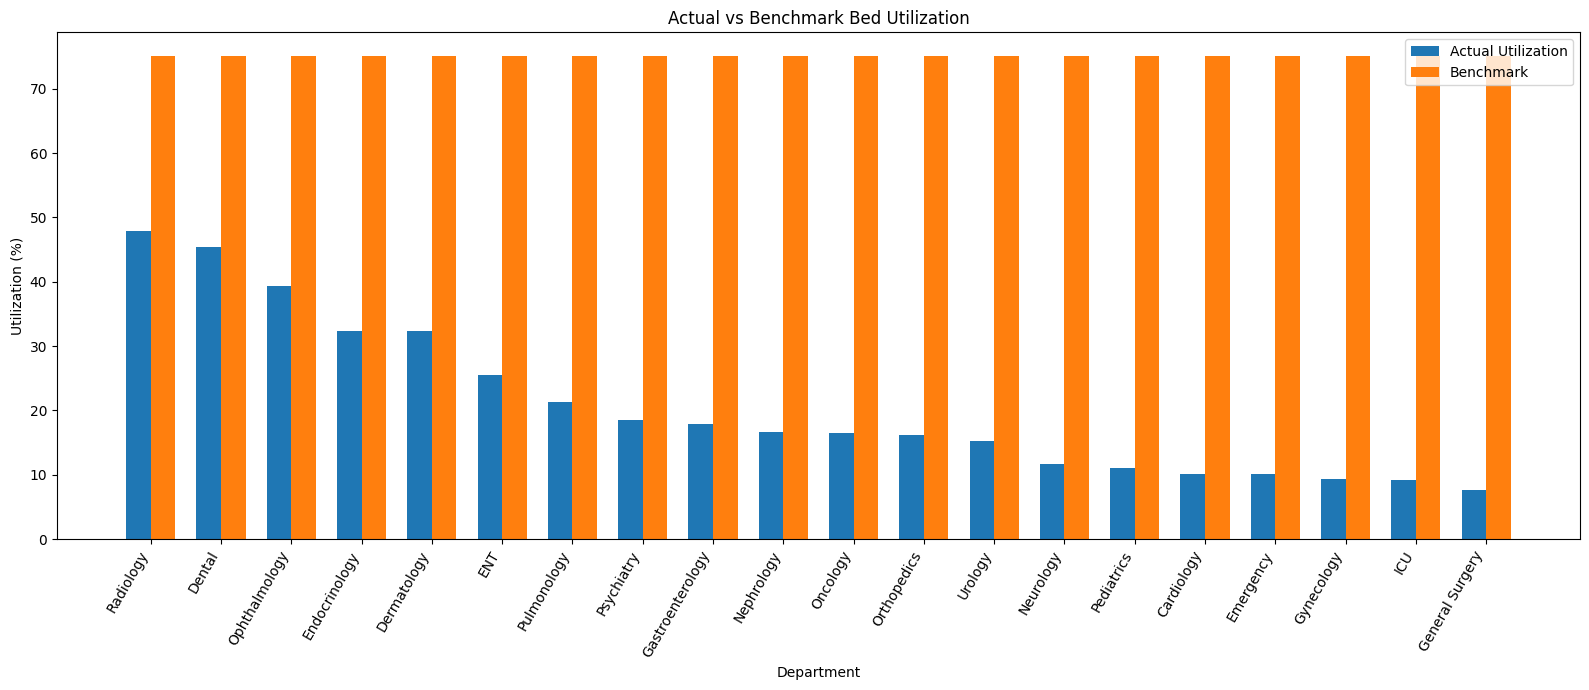

In [70]:
plot_data = final_capacity_analysis.sort_values(
    "Actual_Utilization_Pct",
    ascending=False
)

x = np.arange(len(plot_data))
width = 0.35

plt.figure(figsize=(16, 7))

plt.bar(
    x - width/2,
    plot_data["Actual_Utilization_Pct"],
    width,
    label="Actual Utilization"
)

plt.bar(
    x + width/2,
    plot_data["Benchmark_Utilization_Pct"],
    width,
    label="Benchmark"
)

plt.xticks(
    x,
    plot_data["department_name"],
    rotation=60,
    ha="right"
)

plt.ylabel("Utilization (%)")
plt.xlabel("Department")
plt.title("Actual vs Benchmark Bed Utilization")
plt.legend()
plt.tight_layout()
plt.show()

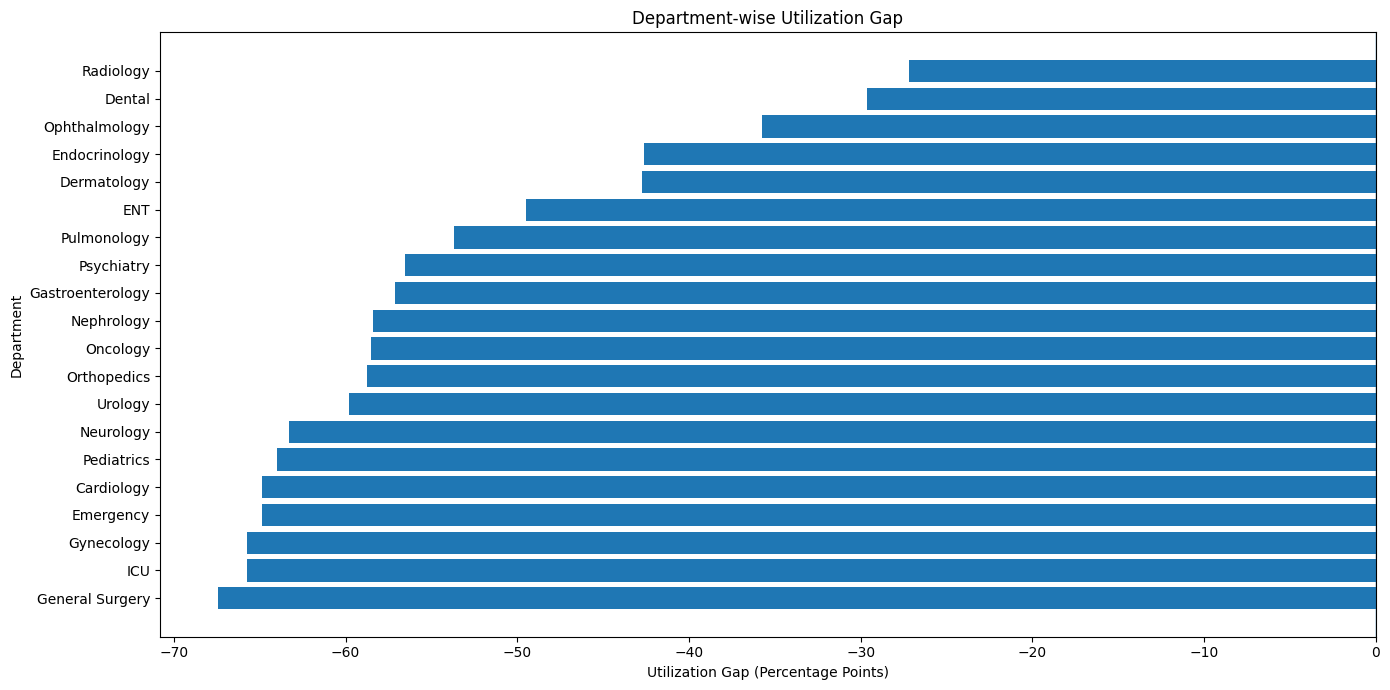

In [71]:
gap_plot = final_capacity_analysis.sort_values(
    "Utilization_Gap_pp"
)

plt.figure(figsize=(14, 7))

plt.barh(
    gap_plot["department_name"],
    gap_plot["Utilization_Gap_pp"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Utilization Gap (Percentage Points)")
plt.ylabel("Department")
plt.title("Department-wise Utilization Gap")

plt.tight_layout()
plt.show()

In [72]:
total_beds = final_capacity_analysis["Total_Beds"].sum()

print("Total Beds:", total_beds)

Total Beds: 560


In [73]:
total_admissions = final_capacity_analysis["Admissions"].sum()

print("Total Admissions:", total_admissions)

Total Admissions: 5000


In [74]:
total_occupied_bed_days = (
    final_capacity_analysis["Occupied_Bed_Days"].sum()
)

print(
    "Total Occupied Bed-Days:",
    total_occupied_bed_days
)

Total Occupied Bed-Days: 27577


In [75]:
overall_utilization = (
    final_capacity_analysis["Occupied_Bed_Days"].sum()
    /
    final_capacity_analysis["Available_Bed_Days"].sum()
) * 100

print(
    "Overall Utilization:",
    round(overall_utilization, 2),
    "%"
)

Overall Utilization: 15.89 %


In [76]:
departments_below = (
    final_capacity_analysis[
        final_capacity_analysis["Utilization_Gap_pp"] < 0
    ]
    .shape[0]
)

print(
    "Departments Below Benchmark:",
    departments_below
)

Departments Below Benchmark: 20


In [77]:
departments_above = (
    final_capacity_analysis[
        final_capacity_analysis["Utilization_Gap_pp"] > 0
    ]
    .shape[0]
)

print(
    "Departments Above Benchmark:",
    departments_above
)

Departments Above Benchmark: 0


In [78]:
significant_gap_count = (
    final_capacity_analysis[
        final_capacity_analysis["Absolute_Gap_pp"] >= 10
    ]
    .shape[0]
)

print(
    "Significant Gap Departments:",
    significant_gap_count
)

Significant Gap Departments: 20


In [79]:
top_priority_departments = (
    final_capacity_analysis
    .sort_values(
        "Absolute_Gap_pp",
        ascending=False
    )
    .head(5)
)

display(
    top_priority_departments[
        [
            "department_name",
            "Actual_Utilization_Pct",
            "Benchmark_Utilization_Pct",
            "Utilization_Gap_pp",
            "Gap_Status"
        ]
    ]
)

,department_name,Actual_Utilization_Pct,Benchmark_Utilization_Pct,Utilization_Gap_pp,Gap_Status
0,General Surgery,7.56,75,-67.44,Significant Underutilization
1,ICU,9.24,75,-65.76,Significant Underutilization
2,Gynecology,9.28,75,-65.72,Significant Underutilization
3,Emergency,10.11,75,-64.89,Significant Underutilization
4,Cardiology,10.13,75,-64.87,Significant Underutilization


In [80]:
doctor_counts = (
    doctors
    .groupby("Department_ID")
    .size()
    .reset_index(name="Doctor_Count")
)

display(doctor_counts)

,Department_ID,Doctor_Count
0,D001,23
1,D002,20
2,D003,30
3,D004,27
4,D005,33
5,D006,21
6,D007,20
7,D008,18
8,D009,17
9,D010,22


In [81]:
final_capacity_analysis = final_capacity_analysis.merge(
    doctor_counts,
    left_on="department_id",
    right_on="Department_ID",
    how="left"
)

In [82]:
final_capacity_analysis["Doctor_Count"] = (
    final_capacity_analysis["Doctor_Count"]
    .fillna(0)
)

In [83]:
final_capacity_analysis["Beds_Per_Doctor"] = np.where(
    final_capacity_analysis["Doctor_Count"] > 0,
    final_capacity_analysis["Total_Beds"]
    / final_capacity_analysis["Doctor_Count"],
    np.nan
)

In [84]:
final_capacity_analysis.to_csv(
    "department_capacity_gap_analysis.csv",
    index=False
)

In [ ]:
# Benchmark & Capacity Gap Analysis – Analysis and Interpretation

## 1. Objective

The objective of this analysis was to evaluate healthcare resource utilization at the department level by comparing actual bed utilization with the defined benchmark or target. The analysis focuses on identifying departments where resource utilization differs significantly from the expected level and highlighting potential capacity-management issues.

The analysis integrates department-level admission information with bed-capacity information to create a consolidated view of healthcare resource utilization. The resulting metrics are intended to support operational decision-making, resource planning, and performance monitoring.

---

## 2. Data Used

The analysis primarily used the following datasets:

* **Admissions dataset** – used to obtain department-level admissions, admission and discharge information, and Length of Stay (LOS).
* **Bed Capacity dataset** – used to obtain the number of beds available for each department.
* **Doctors/Staffing dataset** – used as a supporting resource-management dataset for department-level staffing metrics where applicable.

The datasets were examined for their structure, missing values, duplicate records, data types, and consistency of department identifiers before performing the analysis.

---

## 3. Data Preparation and Validation

The admissions and capacity datasets were prepared for department-level analysis. Date columns were converted into appropriate datetime formats so that the analysis period could be determined correctly.

The data was also checked for:

* Missing values
* Duplicate records
* Duplicate admission identifiers
* Invalid or negative Length of Stay values
* Consistency of department identifiers
* Validity of bed-capacity values

These validation steps were performed to ensure that the calculations used for utilization and capacity analysis were based on reliable and consistent data.

---

## 4. Department-Level Admission Analysis

Admissions were aggregated by department to determine the total number of admissions handled by each department.

This provides an understanding of the workload and patient demand across different departments. Departments with a larger number of admissions represent areas with comparatively higher patient throughput during the analysis period.

The department-level admission information was subsequently combined with bed-capacity information to evaluate whether available resources were appropriately aligned with patient demand.

---

## 5. Length of Stay and Occupied Bed-Days

Length of Stay (LOS) was used to estimate the number of days for which hospital beds were occupied.

For each department, total patient days were calculated by aggregating the Length of Stay values:

**Total Occupied Bed-Days = Sum of Length of Stay**

Occupied bed-days provide a more meaningful measure of bed usage than simply counting the number of admissions because patients may stay for different lengths of time.

For example, two departments may have the same number of admissions but significantly different bed requirements if patients in one department have longer average stays.

Average Length of Stay was also calculated at the department level as a supporting operational KPI.

---

## 6. Available Bed Capacity

The total number of beds available in each department was obtained from the bed-capacity dataset.

Available bed-days were calculated using the number of beds and the analysis period:

**Available Bed-Days = Total Beds × Number of Analysis Days**

This represents the theoretical maximum number of bed-days that could be provided by each department during the selected analysis period.

The calculation allows occupied bed-days to be compared with the capacity actually available during the same period.

---

## 7. Actual Bed Utilization

Actual bed utilization was calculated using occupied bed-days relative to available bed-days:

**Actual Utilization (%) =
(Occupied Bed-Days / Available Bed-Days) × 100**

This metric indicates how much of the available bed capacity was utilized during the analysis period.

A higher utilization rate indicates greater use of available bed capacity, whereas a lower utilization rate indicates that a larger proportion of the available capacity remained unused during the analysis period.

This approach provides a more appropriate historical utilization measure because it considers both the duration of patient stays and the total bed capacity available over time.

---

## 8. Benchmark Comparison

The actual utilization calculated for each department was compared against the defined utilization benchmark or target.

The benchmark provides a reference point for evaluating whether a department is operating below, at, or above the expected utilization level.

The comparison was performed at the department level so that differences between individual departments could be identified rather than relying only on an overall hospital-level utilization value.

The analysis therefore provides visibility into areas where capacity utilization may require further operational attention.

---

## 9. Utilization Gap Calculation

The difference between actual utilization and the benchmark was calculated using:

**Utilization Gap = Actual Utilization − Benchmark Utilization**

The gap is expressed in **percentage points**.

For example, if a department has an actual utilization of 72% and a benchmark of 80%, the utilization gap is:

**72% − 80% = −8 percentage points**

A negative gap indicates that actual utilization is below the benchmark, while a positive gap indicates that utilization is above the benchmark.

Using percentage points makes the comparison clear and avoids confusing the difference between utilization rates with a relative percentage change.

---

## 10. Identification of Significant Gaps

Departments were evaluated according to the size and direction of their utilization gaps.

Departments with substantial negative gaps were identified as areas of relatively lower utilization compared with the benchmark. These departments may require further investigation to understand whether available capacity is being underutilized or whether patient demand is lower than expected.

Departments with substantial positive gaps were identified as areas of higher utilization and potential capacity pressure. Persistently high utilization may indicate that available capacity is being heavily utilized and that operational teams should monitor resource availability carefully.

The gap analysis therefore helps prioritize departments that require further capacity or resource-management attention.

---

## 11. Department Ranking

Departments were ranked according to the magnitude of their utilization gap.

This ranking helps identify the departments that are furthest from the expected benchmark and allows management to focus attention on the most significant capacity-related differences.

The ranking can be used to support:

* Capacity planning
* Resource allocation
* Department-level performance monitoring
* Operational improvement
* Identification of potential underutilization
* Identification of potential capacity pressure

---

## 12. Supporting Resource Metrics

In addition to bed utilization, supporting department-level resource indicators such as admissions, average Length of Stay, doctor count, and beds per doctor can be used to provide additional operational context.

These indicators help explain differences in utilization and provide a broader view of healthcare resource management.

For example, a department with high patient demand and limited available resources may require closer monitoring than a department with similar bed utilization but substantially lower workload.

These supporting metrics are therefore useful for interpreting the capacity-gap results rather than relying on utilization alone.

---

## 13. Benchmark vs Actual Visualization

A benchmark-versus-actual utilization chart was created to visually compare each department's actual bed utilization with its target or benchmark.

The visualization allows differences between actual and expected utilization to be identified quickly.

Departments where the actual utilization is below the benchmark can be easily distinguished from departments where utilization is above the benchmark.

This visualization provides an intuitive overview of department-level performance and supports faster identification of areas requiring further investigation.

---

## 14. Utilization Gap Visualization

A department-wise utilization-gap visualization was also prepared to highlight the magnitude of the difference between actual utilization and the benchmark.

Sorting departments according to their utilization gap makes the largest deviations more visible.

This visualization directly supports the requirement to identify departments with significant capacity or utilization gaps.

---

## 15. KPI Dashboard and Performance Scorecard

The analysis was designed to support a healthcare resource-management KPI dashboard.

The key performance indicators include:

* **Total Beds**
* **Total Admissions**
* **Occupied Bed-Days**
* **Overall Bed Utilization**
* **Departments Below Benchmark**
* **Departments Above Benchmark**
* **Departments with Significant Gaps**

A department-level performance scorecard was also prepared containing:

* Department
* Total Beds
* Admissions
* Occupied Bed-Days
* Actual Utilization
* Benchmark Utilization
* Utilization Gap
* Gap Status

The scorecard provides a consolidated view of resource utilization and makes it easier to identify departments that require operational attention.

---

## 16. Business Interpretation

The analysis provides a department-level understanding of how available bed capacity is being utilized relative to the expected benchmark.

Departments below the benchmark may indicate comparatively lower utilization of available capacity and may require investigation into patient demand, resource allocation, scheduling, or other operational factors.

Departments above the benchmark may indicate higher demand and greater pressure on available resources. Such departments should be monitored to ensure that high utilization does not create operational constraints.

Importantly, the analysis does not treat a higher utilization rate as automatically better or a lower utilization rate as automatically worse. The appropriate interpretation depends on the defined benchmark and the operational context of each department.

---

## 17. Final Outcome

The Benchmark & Capacity Gap Analysis converts raw admission and bed-capacity information into actionable department-level resource-management metrics.

The analysis follows the process:

**Admissions Data → Patient Days → Available Bed Capacity → Actual Utilization → Benchmark Comparison → Utilization Gap → Significant Gap Identification → KPI Scorecard**

The final analytical dataset can be used as an input for the Power BI dashboard. The dashboard provides management with a consolidated view of bed capacity, utilization performance, benchmark deviations, and departments requiring attention.

Overall, this analysis supports the healthcare operations objective of improving visibility into resource utilization and enabling data-driven capacity-management decisions.
